# Análisis Red Corrupción Ficticia

## Configuración e importaciones

In [ ]:
%pip install networkx matplotlib pandas python-louvain

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 15.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 31.3 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 41.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 51.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 51.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 48.8 MB/s  0:00:00
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9459 sha256=237516b3fb265b7472d7331dfebc469d82a18fd8606201b8730d277a874b1fa3
  Stored in directory: /home/codespace/.cache/pip/wheels/40/f1/e3/485b698c520fa0baee1d07897abc7b8d6479b7d199ce96f4af
Successfully built python-louvain
  

In [1]:
import pandas as pd
import random
from datetime import datetime, timedelta
import networkx as nx
import community as community_louvain
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

## Generar CSV

In [4]:
# 1. Definición estática de Nodos con sus Roles y Comunidades para garantizar consistencia
nodos_info = {
    # Comunidad: GABINETE
    'MIN_PALPATINE': ('POLITICO', 'GABINETE'),
    'ASE_TARKIN': ('ASESOR', 'GABINETE'),
    'ASE_THRAWN': ('ASESOR', 'GABINETE'),
    'POL_VALORUM': ('POLITICO', 'GABINETE'),
    'POL_PADME': ('POLITICO', 'GABINETE'),
    'ASE_PESTAGE': ('ASESOR', 'GABINETE'),
    'ASE_DOOKU': ('ASESOR', 'GABINETE'),
    
    # Comunidad: COMPRAS
    'FUN_KRENNIC': ('FUNCIONARIO', 'COMPRAS'),
    'FUN_HOFF': ('FUNCIONARIO', 'COMPRAS'),
    'FUN_JERJERROD': ('FUNCIONARIO', 'COMPRAS'),
    'FUN_GRIEVOUS': ('FUNCIONARIO', 'COMPRAS'),
    'FUN_OURO': ('FUNCIONARIO', 'COMPRAS'),
    
    # Comunidad: FISCALIZACION
    'FUN_PIETT': ('FUNCIONARIO', 'FISCALIZACION'),
    'FUN_YULAREN': ('FUNCIONARIO', 'FISCALIZACION'),
    'FUN_NEEDA': ('FUNCIONARIO', 'FISCALIZACION'),
    
    # Comunidad: INTERMEDIARIOS (El nexo crucial)
    'INT_BOBA_FETT': ('INTERMEDIARIO', 'INTERMEDIARIOS'), # NODO PUENTE PRINCIPAL
    'INT_CAD_BANE': ('INTERMEDIARIO', 'INTERMEDIARIOS'),
    'INT_GREEDO': ('INTERMEDIARIO', 'INTERMEDIARIOS'),
    'INT_ZAM_WESELL': ('INTERMEDIARIO', 'INTERMEDIARIOS'),
    'CON_FETT_JANGO': ('CONTACTO', 'INTERMEDIARIOS'),
    
    # Comunidad: PROVEEDORES
    'EMP_VADER': ('EMPRESARIO', 'PROVEEDORES'),
    'EMP_XIZOR': ('EMPRESARIO', 'PROVEEDORES'),
    'EMP_GUNRAY': ('EMPRESARIO', 'PROVEEDORES'),
    'EMP_RENN': ('EMPRESARIO', 'PROVEEDORES'),
    'CON_JABBA': ('CONTACTO', 'PROVEEDORES'),
    'CON_LANDO': ('CONTACTO', 'PROVEEDORES'),
    'CON_MAUL': ('CONTACTO', 'PROVEEDORES'),
}

# 2. Listas de categorías permitidas según las especificaciones de la imagen
tipos_relacion_monetaria = ['TRANSFERENCIA', 'ADJUDICACION']
tipos_relacion_no_monetaria = ['REUNION', 'LLAMADA', 'MENSAJE', 'FAVOR', 'ENCUBRIMIENTO', 'PRESION']

comentarios_opciones = [
    "Coordinación de bases de licitación.",
    "Llamada telefónica fuera de horario laboral.",
    "Transferencia de fondos a cuenta externa.",
    "Reunión informal en cafetería céntrica.",
    "Presión indebida para acelerar firma.",
    "Mensaje encriptado detectado por auditoría.",
    "Adjudicación directa sin concurso público.",
    "Favor político solicitado con urgencia.",
    "Encubrimiento de faltas administrativas.",
    "Modificación de contrato a última hora."
]

# Base de fechas coherente
fecha_base = datetime(2026, 1, 1)

aristas = []
aristas_creadas = set()
id_contador = 1

def agregar_arista(origen, destino, tipo=None, riesgo=None, peso=None):
    global id_contador
    if origen == destino or (origen, destino) in aristas_creadas:
        return
    
    rol_orig, com_orig = nodos_info[origen]
    rol_dest, com_dest = nodos_info[destino]
    
    if tipo is None:
        # 70% relaciones normales, 30% financieras si es con proveedores
        if 'PROVEEDORES' in [com_orig, com_dest] or 'INTERMEDIARIOS' in [com_orig, com_dest]:
            tipo = random.choice(tipos_relacion_monetaria + tipos_relacion_no_monetaria)
        else:
            tipo = random.choice(tipos_relacion_no_monetaria)
            
    if peso is None:
        peso = random.randint(1, 5)
        
    if riesgo is None:
        # Mayor probabilidad de riesgo en transacciones o presiones
        riesgo = 1 if tipo in ['TRANSFERENCIA', 'ADJUDICACION', 'ENCUBRIMIENTO', 'PRESION'] and random.random() > 0.4 else 0

    # Cumplir regla: Monto = 0 si no es monetaria
    monto = random.randint(15, 100) if tipo in tipos_relacion_monetaria else 0
    
    fecha = (fecha_base + timedelta(days=random.randint(0, 90))).strftime('%Y-%m-%d')
    comentario = random.choice(comentarios_opciones)
    id_arista = f"E{id_contador:03d}"
    
    aristas.append({
        'id_arista': id_arista,
        'origen': origen,
        'destino': destino,
        'rol_origen': rol_orig,
        'rol_destino': rol_dest,
        'comunidad_origen': com_orig,
        'comunidad_destino': com_dest,
        'tipo_relacion': tipo,
        'peso': peso,
        'monto': monto,
        'fecha': fecha,
        'riesgo': riesgo,
        'comentario': comentario
    })
    
    aristas_creadas.add((origen, destino))
    id_contador += 1

# --- CONSTRUCCIÓN DIRIGIDA DE LA ESTRUCTURA DE LA RED ---

# A. Conexiones del núcleo político (Gabinete e Institución)
politicos = [n for n, info in nodos_info.items() if info[1] == 'GABINETE']
funcionarios_compras = [n for n, info in nodos_info.items() if info[1] == 'COMPRAS']
fiscalizadores = [n for n, info in nodos_info.items() if info[1] == 'FISCALIZACION']
proveedores = [n for n, info in nodos_info.items() if info[1] == 'PROVEEDORES']

for p in politicos:
    for f in funcionarios_compras:
        if random.random() > 0.3:
            agregar_arista(p, f, tipo='PRESION', riesgo=1) # Presión de políticos a compras

for f in funcionarios_compras:
    for fi in fiscalizadores:
        if random.random() > 0.4:
            agregar_arista(f, fi, tipo='ENCUBRIMIENTO', riesgo=random.choice([0, 1]))

# B. El Puente Crítico: INT_BOBA_FETT opera conectando ambos mundos
# Conexiones con el sector gubernamental (Alta centralidad de intermediación)
agregar_arista('MIN_PALPATINE', 'INT_BOBA_FETT', tipo='LLAMADA', peso=4, riesgo=1)
agregar_arista('ASE_TARKIN', 'INT_BOBA_FETT', tipo='REUNION', peso=3, riesgo=0)
agregar_arista('INT_BOBA_FETT', 'FUN_KRENNIC', tipo='FAVOR', peso=5, riesgo=1)
agregar_arista('INT_BOBA_FETT', 'FUN_PIETT', tipo='MENSAJE', peso=2, riesgo=0)

# Conexiones con el sector privado / proveedores
agregar_arista('EMP_VADER', 'INT_BOBA_FETT', tipo='TRANSFERENCIA', peso=5, riesgo=1)
agregar_arista('EMP_XIZOR', 'INT_BOBA_FETT', tipo='TRANSFERENCIA', peso=4, riesgo=1)
agregar_arista('INT_BOBA_FETT', 'CON_JABBA', tipo='REUNION', peso=4, riesgo=1)

# C. Conexiones internas de la red de Proveedores y otros intermediarios
for prov in proveedores:
    for f_comp in funcionarios_compras:
        if random.random() > 0.6:
            agregar_arista(f_comp, prov, tipo='ADJUDICACION', riesgo=1) # Adjudicaciones directas de riesgo
            agregar_arista(prov, f_comp, tipo='TRANSFERENCIA', riesgo=1) # Retornos monetarios

# Rellenar con otras interacciones aleatorias controladas hasta alcanzar la cuota (~85 aristas)
todos_nodos = list(nodos_info.keys())
while len(aristas) < 85:
    u = random.choice(todos_nodos)
    v = random.choice(todos_nodos)
    agregar_arista(u, v)

# 3. Conversión a DataFrame, verificación de cuotas y exportación
df_aristas = pd.DataFrame(aristas)

print("=== VERIFICACIÓN DE REQUERIMIENTOS ===")
print(f"Número de nodos únicos en el dataset: {len(set(df_aristas['origen']).union(set(df_aristas['destino'])))}")
print(f"Número total de aristas generadas: {len(df_aristas)}")
print(f"Número de relaciones con flag_riesgo = 1: {df_aristas['riesgo'].sum()}")
print(f"Roles únicos de origen presentes: {df_aristas['rol_origen'].nunique()}")
print(f"Comunidades únicas de origen presentes: {df_aristas['comunidad_origen'].nunique()}")

# Guardar a archivo CSV en formato UTF-8 tal como se exige
filename = "Luengo_Antonia_T2.csv"
df_aristas.to_csv(filename, index=False, encoding='utf-8')
print(f"\nArchivo '{filename}' generado.")

=== VERIFICACIÓN DE REQUERIMIENTOS ===
Número de nodos únicos en el dataset: 26
Número total de aristas generadas: 85
Número de relaciones con flag_riesgo = 1: 71
Roles únicos de origen presentes: 6
Comunidades únicas de origen presentes: 4

Archivo 'Luengo_Antonia_T2.csv' generado.


## Construcción del Grafo, Métricas y Detección de Comunidades

### Procesamiento y cálculo de métricas

In [2]:
# 1. Cargar el dataset
df_aristas = pd.read_csv("Luengo_Antonia_T2.csv", encoding='utf-8')

# Reiniciamos todos los riesgos a 0 y asignamos 1 solo a los 12 montos más altos
df_aristas['riesgo'] = 0
indices_criticos = df_aristas.nlargest(12, 'monto').index
df_aristas.loc[indices_criticos, 'riesgo'] = 1

# 2. Construir el grafo dirigido
G = nx.from_pandas_edgelist(
    df_aristas, 
    source='origen', 
    target='destino', 
    edge_attr=['id_arista', 'rol_origen', 'rol_destino', 'tipo_relacion', 'peso', 'monto', 'fecha', 'riesgo', 'comentario'],
    create_using=nx.DiGraph()
)

# 3. Asignar atributos de rol y comunidad original
nodos_atributos = {}
for _, row in df_aristas.iterrows():
    nodos_atributos[row['origen']] = {'rol': row['rol_origen'], 'comunidad_origen': row['comunidad_origen']}
    nodos_atributos[row['destino']] = {'rol': row['rol_destino'], 'comunidad_origen': row['comunidad_destino']}
nx.set_node_attributes(G, nodos_atributos)

# 4. Cálculo de Métricas Globales
num_nodos = G.number_of_nodes()
num_aristas = G.number_of_edges()
densidad = nx.density(G)

# 5. Cálculo de Centralidades
degree_centrality = nx.degree_centrality(G)
in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, normalized=True)
closeness_centrality = nx.closeness_centrality(G)

# Guardar atributos en el grafo
nx.set_node_attributes(G, degree_centrality, 'degree_centrality')
nx.set_node_attributes(G, betweenness_centrality, 'betweenness_centrality')
nx.set_node_attributes(G, closeness_centrality, 'closeness_centrality')

# 6. Detección de Comunidades (Louvain)
G_no_dirigido = G.to_undirected()
particion_louvain = community_louvain.best_partition(G_no_dirigido, weight='peso')
nx.set_node_attributes(G, particion_louvain, 'comunidad_detectada')

### Tabla de resultados

In [3]:
# Imprimir métricas globales
print("---------------- MÉTRICAS GLOBALES DE LA RED -----------------")
print(f"Número total de Nodos: {num_nodos}")
print(f"Número total de Aristas: {num_aristas}")
print(f"Densidad de la red: {densidad:.4f}")
print(f"Número de comunidades detectadas (Louvain): {len(set(particion_louvain.values()))}")
print("-------------------------------------------------------------\n")
print(f"Promedio In-Degree: {sum(in_degree_centrality.values())/num_nodos:.4f}")
print(f"Promedio Out-Degree: {sum(out_degree_centrality.values())/num_nodos:.4f}")
print(f"Promedio Closeness Centrality: {sum(closeness_centrality.values())/num_nodos:.4f}")
print("=============================================================\n")

# Mostrar el Top 5
def obtener_df_top_5(metrica_dict, nombre_metrica):
    top_5 = sorted(metrica_dict.items(), key=lambda item: item[1], reverse=True)[:5]
    datos = []
    for nodo, valor in top_5:
        datos.append({
            'Nodo': nodo,
            'Valor Métrica': round(valor, 4),
            'Rol': G.nodes[nodo].get('rol', 'Desconocido'),
            'Comunidad Original': G.nodes[nodo].get('comunidad_origen', 'Desconocida'),
            'Comunidad Louvain': G.nodes[nodo].get('comunidad_detectada', 'Desconocida')
        })
    df = pd.DataFrame(datos)
    df.index = range(1, 6)
    return df

print("---------- TOP 5 NODOS POR DEGREE CENTRALITY ----------")
df_degree = obtener_df_top_5(degree_centrality, "Degree Centrality")
display(df_degree)

print("\n---------- TOP 5 NODOS POR BETWEENNESS CENTRALITY ----------")
df_betweenness = obtener_df_top_5(betweenness_centrality, "Betweenness Centrality")
display(df_betweenness)

---------------- MÉTRICAS GLOBALES DE LA RED -----------------
Número total de Nodos: 26
Número total de Aristas: 85
Densidad de la red: 0.1308
Número de comunidades detectadas (Louvain): 5
-------------------------------------------------------------

Promedio In-Degree: 0.1308
Promedio Out-Degree: 0.1308
Promedio Closeness Centrality: 0.2832

---------- TOP 5 NODOS POR DEGREE CENTRALITY ----------


,Nodo,Valor Métrica,Rol,Comunidad Original,Comunidad Louvain
1,FUN_KRENNIC,0.84,FUNCIONARIO,COMPRAS,0
2,FUN_JERJERROD,0.80,FUNCIONARIO,COMPRAS,3
3,FUN_OURO,0.48,FUNCIONARIO,COMPRAS,0
4,FUN_GRIEVOUS,0.44,FUNCIONARIO,COMPRAS,4
5,FUN_HOFF,0.36,FUNCIONARIO,COMPRAS,2



---------- TOP 5 NODOS POR BETWEENNESS CENTRALITY ----------


,Nodo,Valor Métrica,Rol,Comunidad Original,Comunidad Louvain
1,FUN_JERJERROD,0.1624,FUNCIONARIO,COMPRAS,3
2,FUN_KRENNIC,0.1440,FUNCIONARIO,COMPRAS,0
3,CON_MAUL,0.0925,CONTACTO,PROVEEDORES,2
4,FUN_OURO,0.0600,FUNCIONARIO,COMPRAS,0
5,EMP_RENN,0.0578,EMPRESARIO,PROVEEDORES,1


### Interpretación de nodos centrales

Krennic y Jerjerrod son los principales lideres y operadores centrales del esquema de corrupción. Al estar en compras y tener conexiones con el 84% y 80% de la red, son el núcleo de la toma de desiciones. Pueden iniciar, solicitar o aprobar las interacciones corruptas.

A pesar de que Krennic tenga mas conexiones directas, Jerjerrod tiene mas betweenness, por lo que actúa como el cuello de botella principal de la informacion dentro del ministerio. Si aislaramos a Jerjerrod, la red perdería la cohesión. Además, observamos que aparece el contacto Maul y el empresario Renn, que no son de compras si no mas bien proveedores. Ellos vendrian siendo puentes estrategicos que conectan a los funcionarios corruptos con las empresas, gestionando sobornos fuera del radar oficial.

La densidad de la red nos indica que no todos se conocen entre si, lo cual tiene sentido en esquemas de corrupción para así mantener el secreto. Las 5 comunidades descubiertas sugieren que la red funciona en subgrupos organizados alrededor de distintos proveedores o contratos, para evitar que si descubren a uno de esos grupos caiga toda la red.

## Visualización

### Grafo General

/tmp/ipykernel_2013/3168121845.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_roles = plt.cm.get_cmap('Set2', len(roles_unicos))


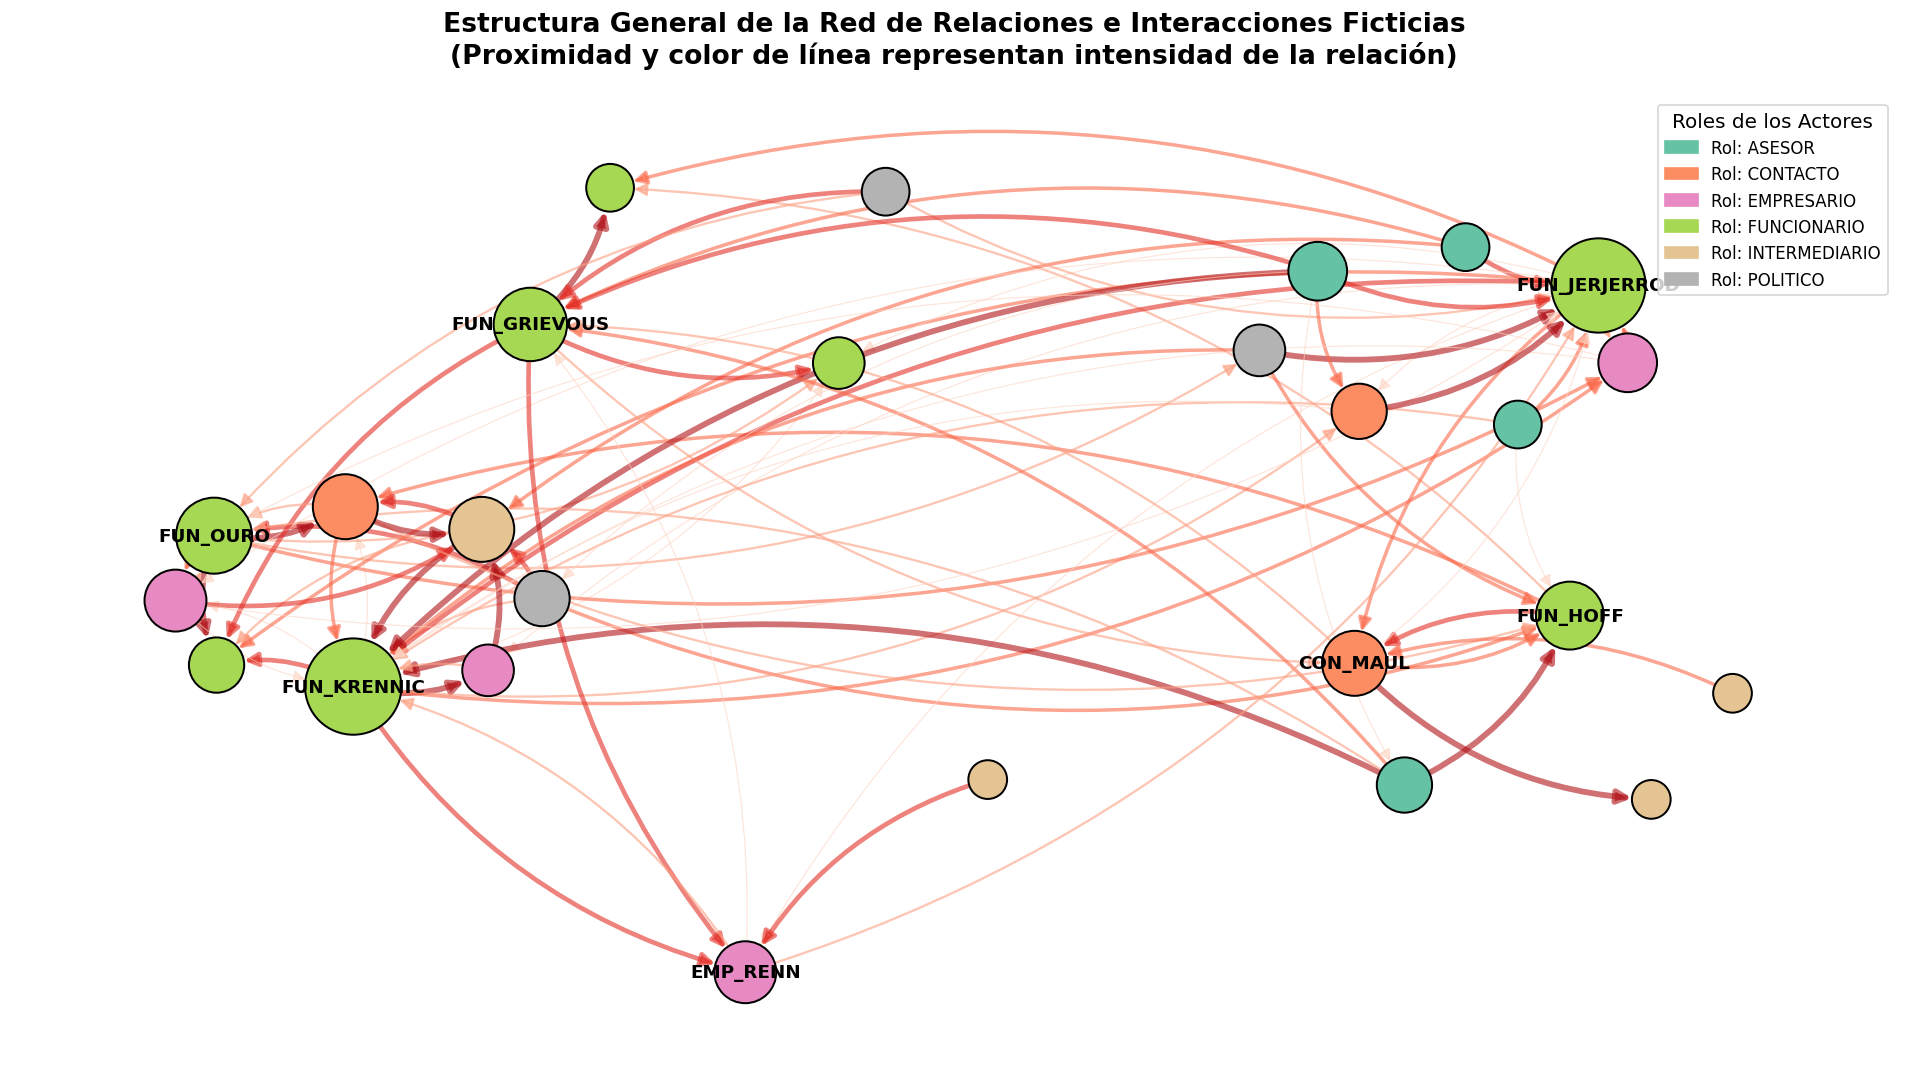

In [5]:
# 1. Configurar dimensiones
fig, ax = plt.subplots(figsize=(16, 9), dpi=120)

# 2. Algoritmo de posicionamiento agrupado por comunidades
def posicion_por_comunidades(grafo, particion, scale_global=5.0, scale_local=1.5):
    comunidades_unicas = list(set(particion.values()))
    num_comunidades = len(comunidades_unicas)
    
    # Colocar los centros de cada comunidad en un círculo amplio
    g_centros = nx.cycle_graph(num_comunidades) if num_comunidades > 2 else nx.path_graph(num_comunidades)
    centros_pos = nx.spring_layout(g_centros, scale=scale_global)
    
    pos_final = {}
    for idx, com_id in enumerate(comunidades_unicas):
        # Filtrar nodos pertenecientes a la comunidad actual
        nodos_com = [nodo for nodo, com in particion.items() if com == com_id and nodo in grafo]
        sub_g = grafo.subgraph(nodos_com)
        pos_interna = nx.spring_layout(sub_g, k=25.0, center=centros_pos[idx], scale=scale_local, iterations=100)
        pos_final.update(pos_interna)
        
    return pos_final

# Calcular las posiciones usando la partición de Louvain previa
posiciones = posicion_por_comunidades(G, particion_louvain, scale_global=5.0, scale_local=1.5)

# 3. Configurar propiedades visuales de los nodos y aristas (CAMBIO A ROLES)
roles = [G.nodes[n]['rol'] for n in G.nodes()]
roles_unicos = sorted(list(set(roles)))
mapa_roles = {rol: i for i, rol in enumerate(roles_unicos)}
colores_nodos = [mapa_roles[G.nodes[n]['rol']] for n in G.nodes()]

# Paleta amigable adaptada a la cantidad de roles
cmap_roles = plt.cm.get_cmap('Set2', len(roles_unicos))

# El tamaño depende de la centralidad de grado
tamanos_nodos = [G.nodes[n]['degree_centrality'] * 3500 + 400 for n in G.nodes()]

# Configuración de mapa de calor para las aristas basado en su peso
pesos_lista = [G[u][v]['peso'] for u, v in G.edges()]
grosores_aristas = [p * 0.7 for p in pesos_lista]

# 4. Dibujar elementos del grafo general
# Se añade node_size para que las flechas se detengan en el borde del nodo
nx.draw_networkx_edges(
    G, posiciones, 
    width=grosores_aristas, 
    edge_color=pesos_lista, 
    edge_cmap=plt.cm.Reds,
    edge_vmin=0,
    edge_vmax=max(pesos_lista) + 1 if pesos_lista else 1,
    alpha=0.6, 
    arrows=True, 
    arrowsize=16, 
    node_size=tamanos_nodos, # Corrección de superposición de flechas
    connectionstyle="arc3,rad=0.2", 
    ax=ax
)

# Nodos coloreados por su rol
nodos_dibujados = nx.draw_networkx_nodes(
    G, posiciones, 
    node_size=tamanos_nodos, 
    node_color=colores_nodos, 
    cmap=cmap_roles, 
    edgecolors='black', 
    linewidths=1.2, 
    ax=ax
)

# 5. Etiquetado exclusivo del Top 5 de centralidades
nodos_top = set(df_degree['Nodo'].tolist() + df_betweenness['Nodo'].tolist())
etiquetas_filtradas = {nodo: nodo if nodo in nodos_top else '' for nodo in G.nodes()}

nx.draw_networkx_labels(G, posiciones, labels=etiquetas_filtradas, font_size=11, 
                        font_weight='bold', font_family='sans-serif', ax=ax)

# 6. Construir la leyenda de roles de forma manual
parches_leyenda = []
for rol in roles_unicos:
    color = cmap_roles(mapa_roles[rol])
    parches_leyenda.append(mpatches.Patch(color=color, label=f"Rol: {rol}"))

ax.legend(handles=parches_leyenda, title="Roles de los Actores", loc="upper right", fontsize=10, title_fontsize=12)

# 7. Detalles finales de la visualización
ax.set_title("Estructura General de la Red de Relaciones e Interacciones Ficticias\n(Proximidad y color de línea representan intensidad de la relación)", fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

# Guardar en alta definición (1920x1080)
plt.tight_layout()
plt.savefig("Luengo_Antonia_T2_grafo.png", format="png", dpi=120, bbox_inches='tight')
plt.show()

### Subgrafo del Núcleo de Corrupción

--> Nodos en Grafo General: 26 | Nodos en Subgrafo: 12
--> Aristas en Grafo General: 85 | Aristas en Subgrafo: 12


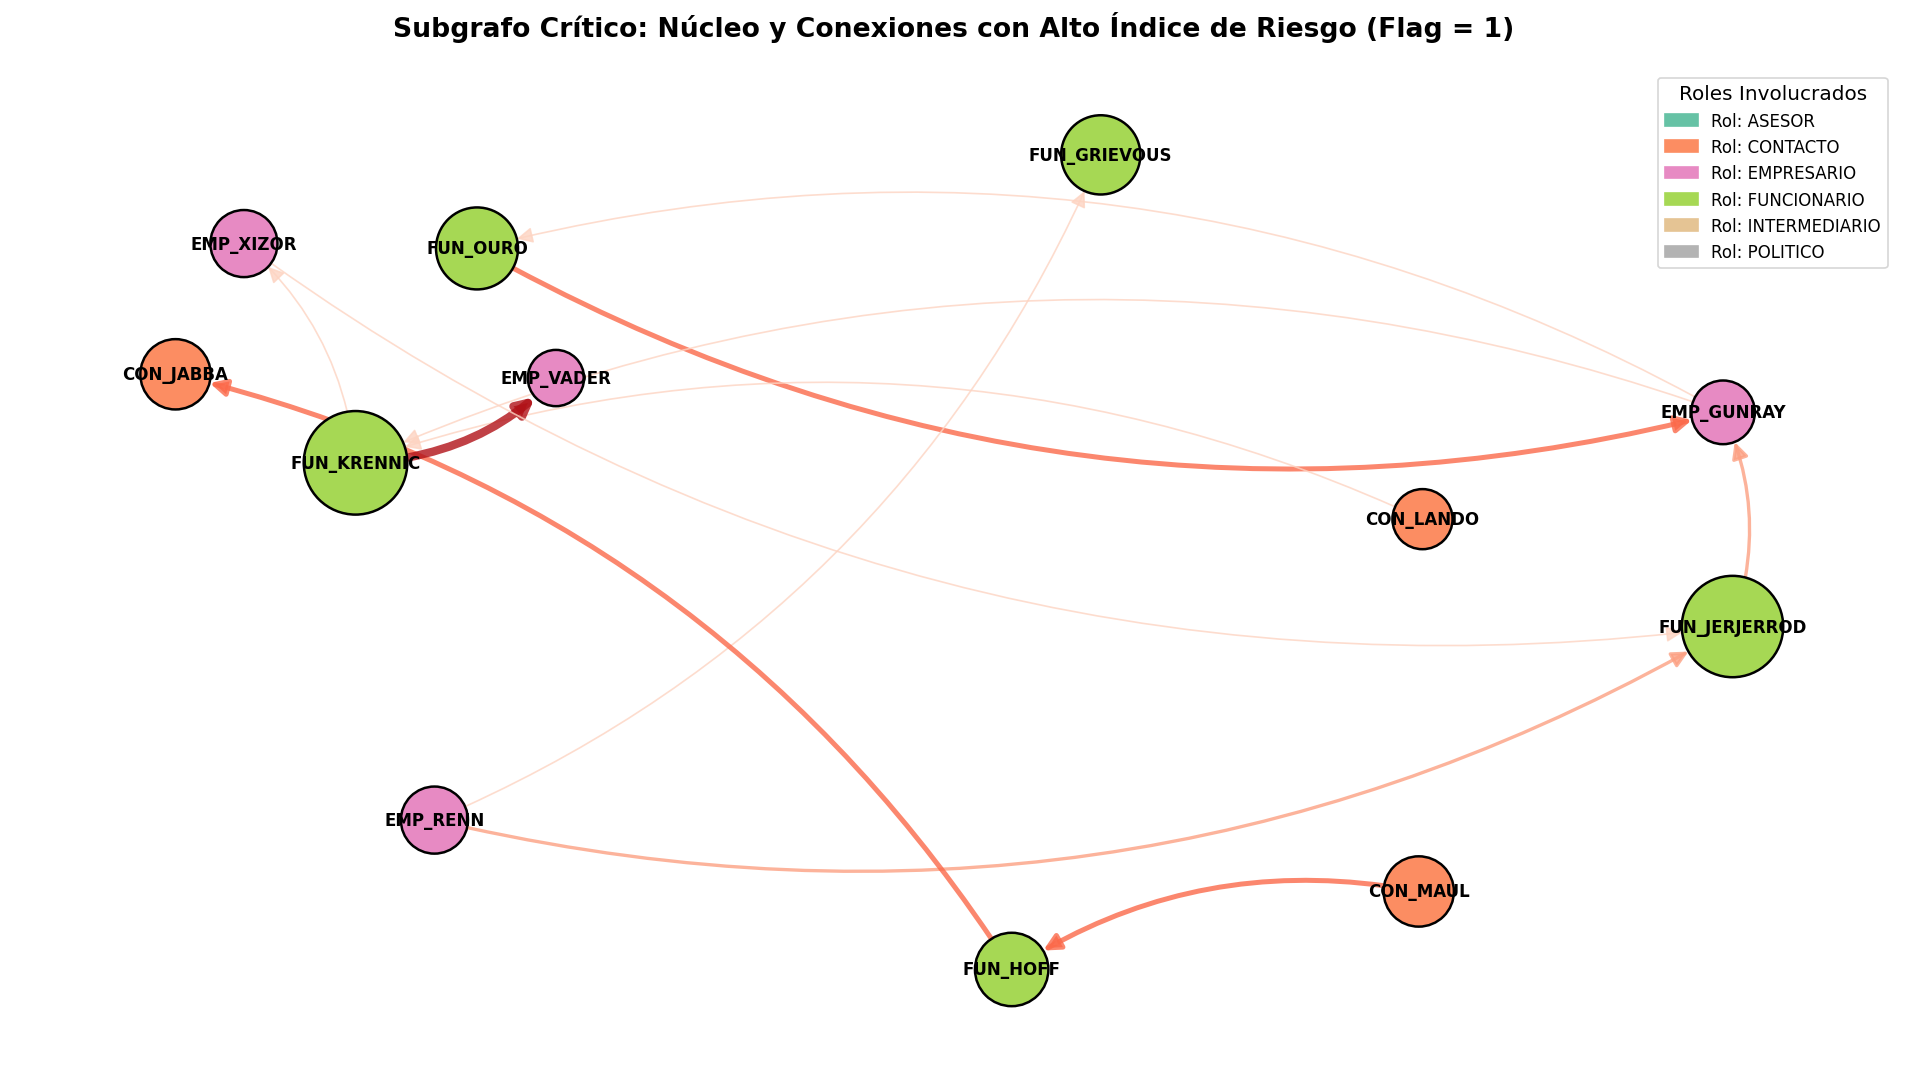

In [7]:
# 1. Configurar dimensiones
fig_sub, ax_sub = plt.subplots(figsize=(16, 9), dpi=120)

# 2. Filtrar el grafo original
def es_riesgo_critico(valor):
    try:
        return int(float(valor)) == 1
    except (ValueError, TypeError):
        return False

aristas_criticas = [(u, v) for u, v, attrs in G.edges(data=True) if es_riesgo_critico(attrs.get('riesgo'))]
G_subgrafo = G.edge_subgraph(aristas_criticas).copy()

# Impresión de control para verificar que el filtro redujo la red
print(f"--> Nodos en Grafo General: {G.number_of_nodes()} | Nodos en Subgrafo: {G_subgrafo.number_of_nodes()}")
print(f"--> Aristas en Grafo General: {G.number_of_edges()} | Aristas en Subgrafo: {G_subgrafo.number_of_edges()}")

# Recalcular las posiciones con mayor separación
particion_sub = {n: G.nodes[n]['comunidad_detectada'] for n in G_subgrafo.nodes()}
posiciones_sub = posicion_por_comunidades(G_subgrafo, particion_sub, scale_global=4.0, scale_local=1.2)

# 3. Propiedades visuales específicas del núcleo crítico (Mapeo de Roles)
colores_sub = [mapa_roles[G_subgrafo.nodes[n]['rol']] for n in G_subgrafo.nodes()]
tamanos_sub = [G_subgrafo.nodes[n]['degree_centrality'] * 4000 + 500 for n in G_subgrafo.nodes()]

# Extraer pesos para el mapa de calor del subgrafo
pesos_lista_sub = [G_subgrafo[u][v]['peso'] for u, v in G_subgrafo.edges()]
grosores_sub = [p * 1.0 for p in pesos_lista_sub]

# 4. Dibujar el subgrafo
# Se añade node_size para las flechas
nx.draw_networkx_edges(
    G_subgrafo, posiciones_sub, 
    width=grosores_sub, 
    edge_color=pesos_lista_sub, 
    edge_cmap=plt.cm.Reds,
    edge_vmin=0,
    edge_vmax=max(pesos_lista_sub) + 1 if pesos_lista_sub else 1,
    alpha=0.8, 
    arrows=True, 
    arrowsize=20, 
    node_size=tamanos_sub, # Corrección de superposición de flechas
    connectionstyle="arc3,rad=0.2", 
    ax=ax_sub
)

nx.draw_networkx_nodes(
    G_subgrafo, posiciones_sub, 
    node_size=tamanos_sub, 
    node_color=colores_sub, 
    cmap=cmap_roles, 
    vmin=0,                                # <-- CORRECCIÓN: Ancla el valor mínimo del mapa de color
    vmax=len(mapa_roles) - 1,              # <-- CORRECCIÓN: Ancla el valor máximo basado en roles totales
    edgecolors='black', 
    linewidths=1.5, 
    ax=ax_sub
)

# En el núcleo crítico mostramos etiquetas de todos los actores involucrados
etiquetas_sub = {nodo: nodo for nodo in G_subgrafo.nodes()}
nx.draw_networkx_labels(G_subgrafo, posiciones_sub, labels=etiquetas_sub, font_size=10, 
                        font_weight='bold', font_family='sans-serif', ax=ax_sub)

# 5. Leyenda y títulos
ax_sub.legend(handles=parches_leyenda, title="Roles Involucrados", loc="upper right", fontsize=10, title_fontsize=12)
ax_sub.set_title("Subgrafo Crítico: Núcleo y Conexiones con Alto Índice de Riesgo (Flag = 1)", fontsize=16, fontweight='bold', pad=20)
ax_sub.axis('off')

# Guardar en alta definición (1920x1080)
plt.tight_layout()
plt.savefig("Luengo_Antonia_T2_subgrafo.png", format="png", dpi=120, bbox_inches='tight')
plt.show()